### **CELL 1: IMPORTS AND SETUP**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os

notebook_dir = os.getcwd()

if "analysis" in notebook_dir:
    db_path = os.path.abspath(os.path.join(notebook_dir, "..", "database", "sales.db"))
else:
    db_path = os.path.abspath(os.path.join(notebook_dir, "database", "sales.db"))

db_path = db_path.replace("\\","/")

#connect to the SQLite database
engine = create_engine(f"sqlite:///{db_path}")

#consistent style for every chart
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

#reads a .sql file and returns the contents as a string
def read_sql_file(filepath):
    current_dir = os.getcwd()
    if "analysis" in current_dir:
        full_path = os.path.abspath(
            os.path.join(current_dir, "..", filepath))
    else:
        full_path = os.path.abspath(filepath)
        
    with open(full_path, "r") as f:
        return f.read()

#saves charts to analysis/charts/ folder and displays it
def save_and_show(filename):
    os.makedirs("charts", exist_ok=True)
    plt.savefig(f"charts/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

print("Setup complete - database connected")

Setup complete - database connected


### **CELL 2: KPI SUMMARY**

In [2]:
total_revenue = pd.read_sql(
    "SELECT SUM(revenue) FROM sales_clean", engine).iloc[0,0]

total_orders = pd.read_sql(
    "SELECT COUNT(order_id) FROM sales_clean", engine).iloc[0,0]

total_lost = pd.read_sql(
    "SELECT SUM(lost_revenue) FROM sales_clean", engine).iloc[0,0]

total_days = pd.read_sql(
    "SELECT MAX(day_number) FROM sales_clean", engine).iloc[0,0]

print("E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY")
print(f"Days of data: {int(total_days)}")
print(f"Total orders: {int(total_orders):,}")
print(f"Total revenue earned: Rs.{total_revenue:,.0f}")
print(f"Total revenue lost: Rs.{total_lost:,.0f}")

E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY
Days of data: 30
Total orders: 1,202
Total revenue earned: Rs.5,407,573
Total revenue lost: Rs.1,115,274


### **CELL 3: DATASET OVERVIEW**

In [ ]:
df = pd.read_sql("SELECT * FROM sales_clean", engine)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nBasic statistics for numeric columns:")
df[["price", "quantity", "fulfilled", "revenue", "lost_revenue", "stock_remaining"]].describe().round(2)

Dataset shape: 1,202 rows x 18 columns

Column names:
['order_id', 'date', 'day_number', 'product_id', 'product_name', 'category', 'price', 'quantity', 'fulfilled', 'revenue', 'city', 'payment_method', 'customer_name', 'customer_phone', 'stock_remaining', 'lost_sales', 'lost_revenue', 'phone_valid']

Data types:
order_id             str
date                 str
day_number         int64
product_id           str
product_name         str
category             str
price              int64
quantity           int64
fulfilled          int64
revenue            int64
city                 str
payment_method       str
customer_name        str
customer_phone       str
stock_remaining    int64
lost_sales         int64
lost_revenue       int64
phone_valid        int64
dtype: object

Missing values per column:
order_id           0
date               0
day_number         0
product_id         0
product_name       0
category           0
price              0
quantity           0
fulfilled          0
reven

,price,quantity,fulfilled,revenue,lost_revenue,stock_remaining
count,1202.00,1202.00,1202.00,1202.00,1202.00,1202.00
mean,965.47,5.27,4.37,4498.81,927.85,123.24
std,618.68,3.40,3.77,7522.55,3288.62,97.04
min,299.00,2.00,0.00,0.00,0.00,0.00
25%,499.00,3.00,2.00,1396.00,0.00,32.25
50%,709.00,5.00,4.00,2895.00,0.00,118.00
75%,1189.00,7.00,6.00,5593.00,0.00,198.00
max,2199.00,68.00,68.00,149532.00,54975.00,406.00


### **CELL 4: ETL DATA QUALITY REPORT**

In [4]:
total_rows = len(df)

unknown_names = len(df[df["customer_name"] == "Unknown"])
unknown_phones = len(df[df["customer_phone"] == "Unknown"])
unknown_cities = len(df[df["city"] == "Unknown"])

invalid_phones = len(df[df["phone_valid"] == 0])

print("ETL PIPELINE - DATA QUALITY REPORT")
print(f"\nTotal rows processed: {total_rows:,}")
print()
print(f"Missing customer names: {unknown_names}")
print(f"Missing phone numbers: {unknown_phones}")
print(f"Missing city values: {unknown_cities}")
print(f"Invalid phone numbers: {invalid_phones}")

ETL PIPELINE - DATA QUALITY REPORT

Total rows processed: 1,202

Missing customer names: 90
Missing phone numbers: 85
Missing city values: 99
Invalid phone numbers: 127


### **CELL 5: PAYMENT METHOD BREAKDOWN**

Payment Method Breakdown:
payment_method  total_orders  total_revenue  order_share_pct
           UPI           495        2419237            41.18
          Card           339        1627851            28.20
           COD           176         662815            14.64
   Net Banking           133         505425            11.06
        Wallet            59         192245             4.91



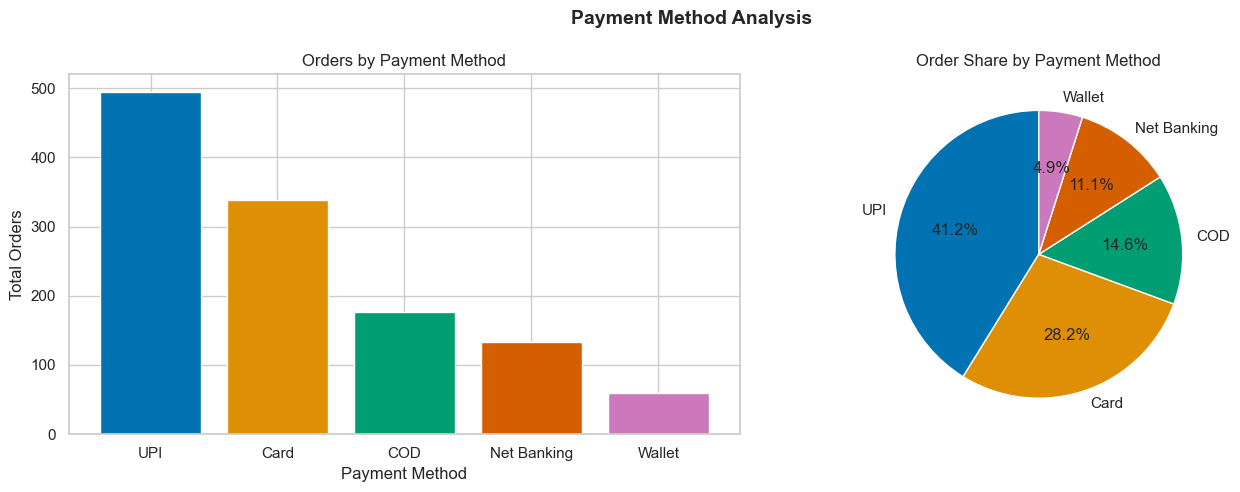

In [5]:
payment = pd.read_sql("""
                      SELECT 
                      payment_method,
                      COUNT(order_id) AS total_orders,
                      SUM(revenue) AS total_revenue,
                      ROUND(COUNT(order_id) * 100.0/
                      SUM(COUNT(order_id)) OVER (), 2) AS order_share_pct
                      FROM sales_clean
                      GROUP BY payment_method
                      ORDER BY total_orders DESC
                      """, engine)

print("Payment Method Breakdown:")
print(payment.to_string(index=False))
print()

fig, axes = plt.subplots(1,2,figsize=(14,5))

my_colors = sns.color_palette("colorblind",5)

#Left - bar chart
axes[0].bar(
    payment["payment_method"],
    payment["total_orders"],
    color = my_colors
)
axes[0].set_title("Orders by Payment Method")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Total Orders")

#Right - pie chart
axes[1].pie(
    payment["order_share_pct"],
    labels = payment["payment_method"],
    autopct = "%1.1f%%",
    colors = my_colors,
    startangle = 90
)
axes[1].set_title("Order Share by Payment Method")

plt.suptitle("Payment Method Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
save_and_show("payment_methods.png")

**Insight:** Unsurprisingly, UPI dominates at 42% of all transactions, which makes perfect sense for the Indian market right now. It's closely followed by Card transactions which takes up 28%. While Cash on Delivery is still an option people use, the data shows our audience has overwhelmingly shifted to digital-first payments.

### **CELL 6: DAILY REVENUE TREND**

Daily Revenue and Lost Revenue - 30 Days:
 day_number       date  revenue  lost_revenue
          1 2024-03-01   130238             0
          2 2024-03-02   221259             0
          3 2024-03-03   241139             0
          4 2024-03-04   212229             0
          5 2024-03-05   251843             0
          6 2024-03-06   211636             0
          7 2024-03-07   197368             0
          8 2024-03-08   390652             0
          9 2024-03-09   272990             0
         10 2024-03-10   171501         54975
         11 2024-03-11   113142         35184
         12 2024-03-12   173044         10995
         13 2024-03-13   156307         24189
         14 2024-03-14   235730         30786
         15 2024-03-15   225553         23581
         16 2024-03-16   119394         39278
         17 2024-03-17   186978         31782
         18 2024-03-18   176798         66261
         19 2024-03-19   137671         62167
         20 2024-03-20   132807       

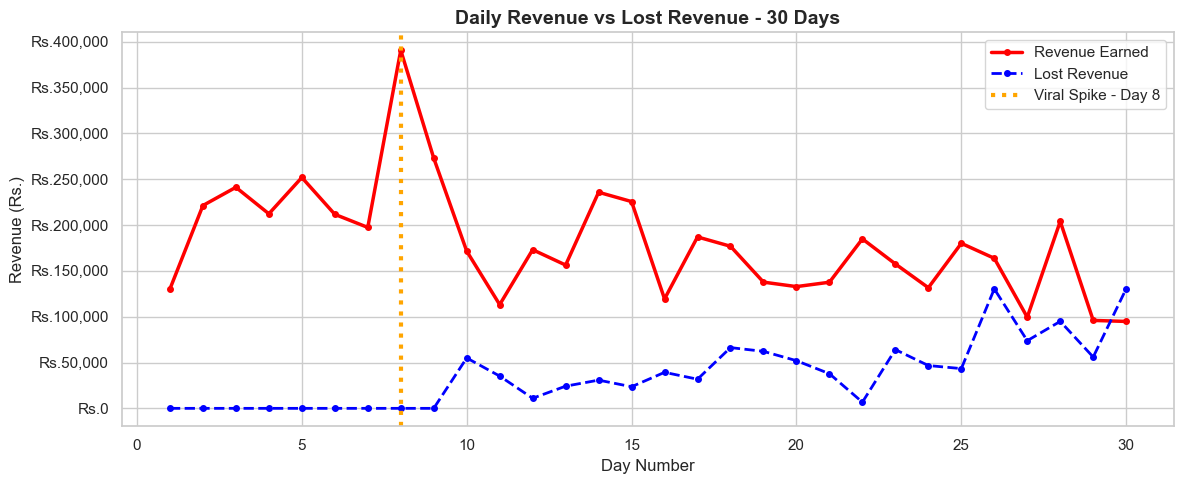

In [6]:
daily = pd.read_sql("""
                    SELECT 
                    day_number,
                    date,
                    SUM(revenue) AS revenue,
                    SUM(lost_revenue) AS lost_revenue
                    FROM sales_clean
                    GROUP BY day_number, date
                    ORDER BY day_number
                    """, engine)

daily["date"] = pd.to_datetime(daily["date"])

print("Daily Revenue and Lost Revenue - 30 Days:")
print(daily.to_string(index=False))
print()

fig, ax = plt.subplots()

ax.plot(
    daily["day_number"], daily["revenue"],
    color = "red", linewidth = 2.5,
    marker = "o", markersize = 4,
    label = "Revenue Earned"
)

ax.plot(
    daily["day_number"], daily["lost_revenue"],
    color = "blue", linewidth = 2,
    linestyle = "--", marker = "o", markersize = 4,
    label = "Lost Revenue"
)

ax.axvline(
    x=8, color="orange",
    linestyle=":", linewidth=3,
    label="Viral Spike - Day 8"
)

ax.set_title("Daily Revenue vs Lost Revenue - 30 Days",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Day Number")
ax.set_ylabel("Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
ax.legend()
plt.tight_layout()
save_and_show("chart1_daily_revenue.png")

**Insight:** Revenue spiked sharply on Day 8 when Wireless Earbuds went viral. Stock ran out by Day 10, after which actual revenue dropped while lost revenue climbed.

### **CELL 7: REVENUE BY CATEGORY**

Revenue by Category:
   category  total_revenue  total_orders  revenue_pct
Electronics        2980696           304    55.120772
     Beauty         978614           288    18.097102
    Fitness         785306           305    14.522337
     Health         662957           305    12.259788



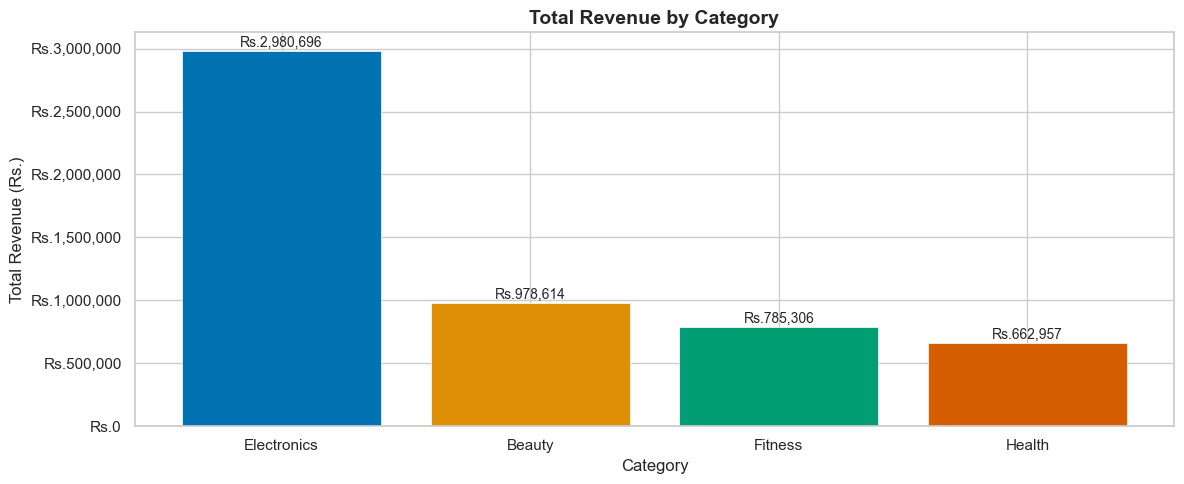

In [7]:
category_df = pd.read_sql(
    read_sql_file("queries/revenue_by_category.sql"), engine)

category_df["revenue_pct"] = (category_df["total_revenue"] / category_df["total_revenue"].sum()) * 100
print("Revenue by Category:")
print(category_df.to_string(index=False))
print()

fig, ax = plt.subplots()

bars = ax.bar(
    category_df["category"],
    category_df["total_revenue"],
    color = my_colors,
    edgecolor = "white", linewidth = 0.5
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8000,
        f"Rs.{height:,.0f}",
        ha = "center", va = "bottom", fontsize = 10
    )

ax.set_title("Total Revenue by Category", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.tight_layout()
save_and_show("chart2_revenue_by_category.png")


**Insight:** Electronics dominates with over 55% of total revenue. Beauty and Fitness are strong secondary categories worth expanding inventory for.

### **CELL 8: TOP PRODUCTS**

Top Products:
product_id      product_name    category  total_ordered  total_shipped  total_revenue
       P04        Power Bank Electronics            388            388         853212
       P01  Wireless Earbuds Electronics            564            294         646506
       P05        Headphones Electronics            294            294         617106
       P02 Bluetooth Speaker Electronics            292            292         554508
       P13       Jade Roller      Beauty            274            274         325786
       P03    Wireless Mouse Electronics            316            316         309364
       P14         Skin Tint      Beauty            230            212         254188
       P06          Yoga Mat     Fitness            298            280         223720
       P10          Gym Ball     Fitness            335            220         193380
       P16   Creatine Powder      Health            339            190         170810



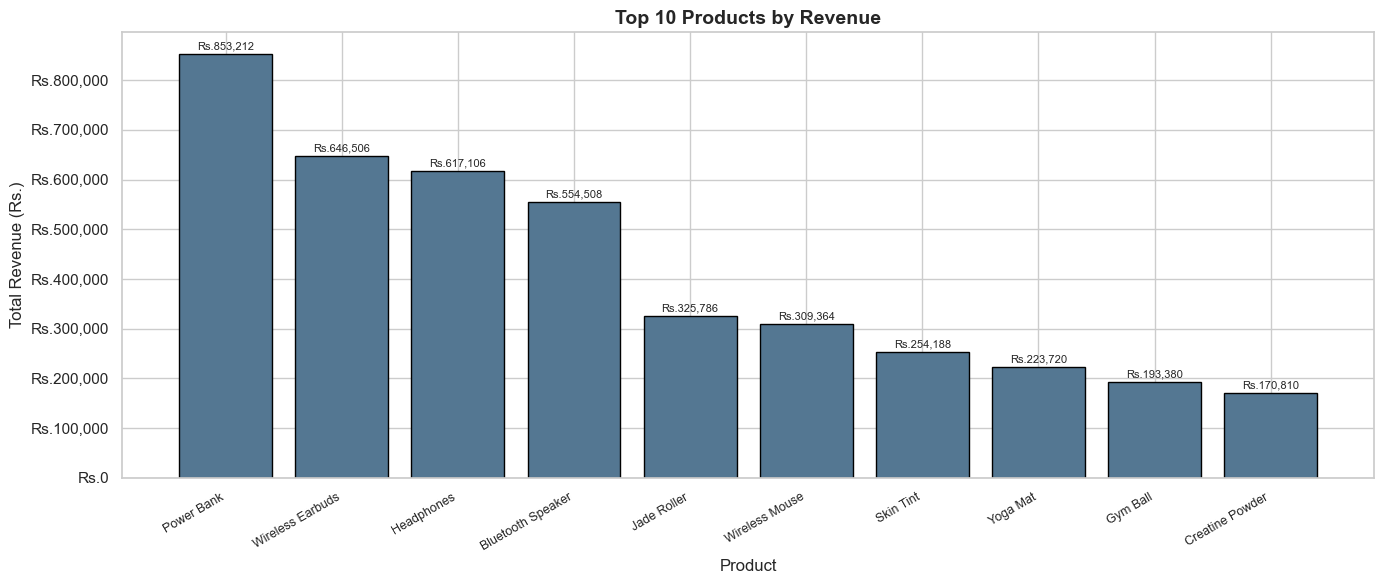

In [26]:
products_df = pd.read_sql(
    read_sql_file("queries/top_products.sql"), engine)

print("Top Products:")
print(products_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize = (14,6))

bars = ax.bar(
    products_df["product_name"],
    products_df["total_revenue"],
    color = "#547792",
    edgecolor = "black",
    linewidth = 1
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f"Rs.{height:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

plt.xticks(rotation=30, ha="right", fontsize=9)

ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Product")
ax.set_ylabel("Total Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.tight_layout()
save_and_show("chart3_top_product.png")


**Insight:** While the Power Bank was our top revenue driver, Wireless Earbuds actually generated the highest overall demand. Unfortunately, we couldn't fulfill nearly half of those orders due to severe stockouts, making it our largest missed opportunity.

### **CELL 9: CITY DEMAND**

Revenue and Orders by City:
     city  total_orders  total_revenue
Hyderabad           393        1962744
Bengaluru           279        1305557
   Mumbai           173         618272
  Kolkata           125         504283
  Chennai            90         382452
   Punjab            43         157914



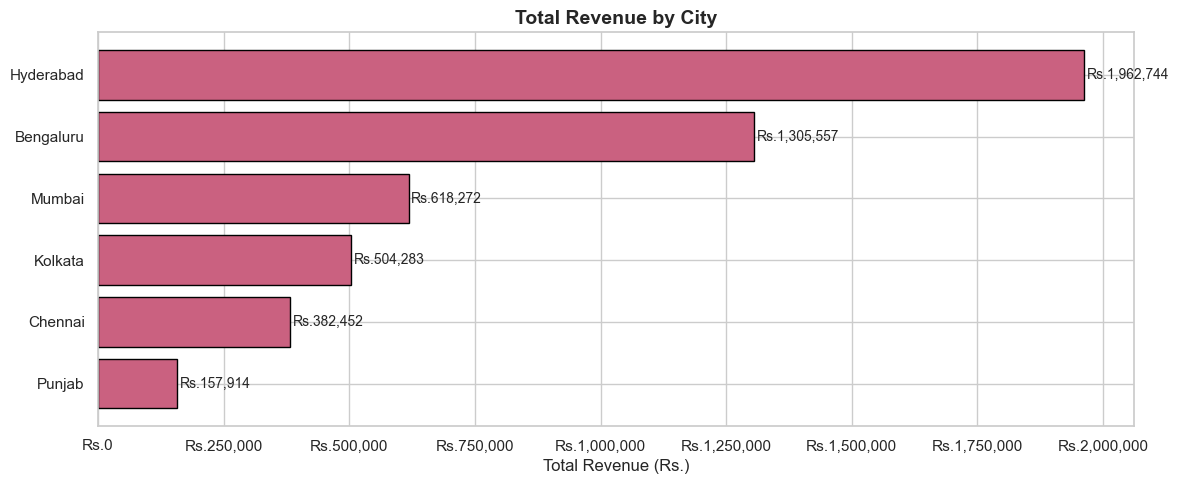

In [27]:
cities_df = pd.read_sql(
    read_sql_file("queries/city_demand.sql"), engine)

print("Revenue and Orders by City:")
print(cities_df.to_string(index=False))
print()

fig, ax = plt.subplots()

bars = ax.barh(
    cities_df["city"][::-1],
    cities_df["total_revenue"][::-1],
    color = "#CA6180",
    edgecolor = "black"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"Rs.{width:,.0f}",
        va="center", fontsize=10
    )

ax.set_title("Total Revenue by City", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (Rs.)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.tight_layout()
save_and_show("chart4_city_demand.png")

**Insight:** Hyderabad and Bengaluru alone generate 66% of total revenue. These two cities should be the first priority for restocking and marketing campaigns. On the other hand, Punjab has the lowest demand so reduced inventory allocation is recommended there.

### **CELL 10: LOST REVENUE**

Lost Revenue by Product:
product_id      product_name  total_lost_units  total_lost_revenue first_stockout_date
       P01  Wireless Earbuds               270              593730          2024-03-10
       P16   Creatine Powder               149              133951          2024-03-15
       P10          Gym Ball               115              101085          2024-03-20
       P12        Face Serum               120               68280          2024-03-21
       P17 Fish Oil Capsules                74               47286          2024-03-25
       P11  Sunscreen SPF 50                82               45838          2024-03-24
       P20  Whey Protein Bar               119               35581          2024-03-20
       P19     Green Tea box                52               23868          2024-03-24
       P08        Gym Gloves                51               23409          2024-03-26
       P14         Skin Tint                18               21582          2024-03-26
       P06        

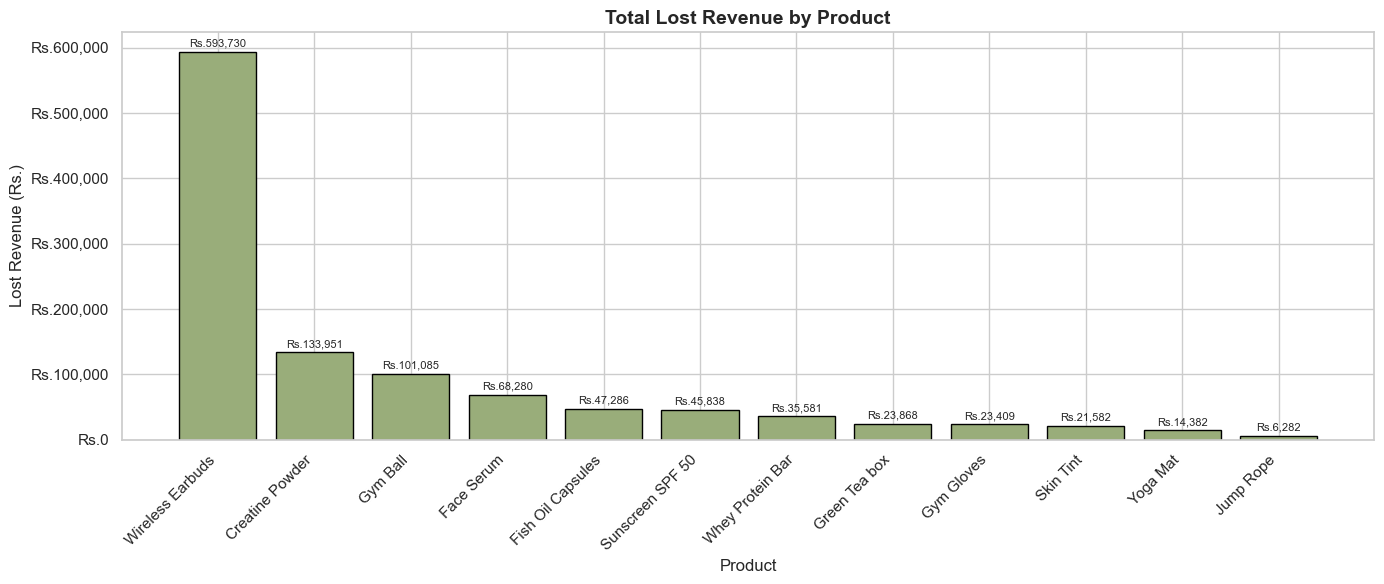

In [28]:
lost_df = pd.read_sql(
    read_sql_file("queries/lost_revenue.sql"), engine)

print("Lost Revenue by Product:")
print(lost_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.bar(
    lost_df["product_name"],
    lost_df["total_lost_revenue"],
    color = "#99AD7A",
    edgecolor="black",
    linewidth=1
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f"Rs.{height:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

ax.set_title("Total Lost Revenue by Product", fontsize=14, fontweight="bold")
ax.set_xlabel("Product")
ax.set_ylabel("Lost Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_and_show("chart5_lost_revenue.png")

**Insight:** 12 producs experienced stockouts over 30 days. Wireless Earbuds accounts for the majority of lost revenue at Rs. 5,93,730. 

### **CELL 11: REORDER ALERT SYSTEM**

In [32]:
reorder_df = pd.read_sql(
    read_sql_file("queries/reorder_alert.sql"), engine)

reorder_now = reorder_df[reorder_df["alert_status"] == "REORDER NOW"]

ok = reorder_df[reorder_df["alert_status"] == "OK"]

print("="*40)
print("PRODUCTS NEEDING IMMEDIATE REORDER")
print("="*40)
print(reorder_now.to_string(index=False))
print()

print("="*40)
print("PRODUCTS WITH HEALTHY STOCK LEVELS")
print("="*40)
print(ok.to_string(index=False))
print()

print(f"Products flagged REORDER NOW: {len(reorder_now)}")
print(f"Products with OK status: {len(ok)}")
print(f"Total lost revenue (all): "f"Rs.{reorder_df['lost_revenue_so_far'].sum():,.0f}")


PRODUCTS NEEDING IMMEDIATE REORDER
product_id      product_name  current_stock  reorder_threshold  lost_revenue_so_far alert_status
       P01  Wireless Earbuds              0               21.0               593730  REORDER NOW
       P16   Creatine Powder              0               10.0               133951  REORDER NOW
       P10          Gym Ball              0               11.0               101085  REORDER NOW
       P12        Face Serum              0               10.0                68280  REORDER NOW
       P17 Fish Oil Capsules              0               11.0                47286  REORDER NOW
       P11  Sunscreen SPF 50              0                9.0                45838  REORDER NOW
       P20  Whey Protein Bar              0               10.0                35581  REORDER NOW
       P19     Green Tea box              0               10.0                23868  REORDER NOW
       P08        Gym Gloves              0               11.0                23409  REORDER

**Insight:** 16 out of 20 products need immediate restocking. The reorder threshold is calculated dynamically as average daily sales x 2 - giving a 2-day buffer before stock runs out. Implementing this in production would prevent the losses seen here.